# Test: Unrotated Multi-Patch Coupler

Verify qubit layout for the multi-patch coupler geometry.  
Reference: `processing/unrotated_multi_coupler.png` (Ex1, Ex2, Ex3).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src.qec_code.surface_code.unrotated import (
    UnrotatedSurfaceCode,
    UnrotatedSurfaceCodeExtractionBlock,
    UnrotatedMultiPatchCoupler,
    UnrotatedTwoPatchCoupler,
)
from src.ir.qec_system import QECSystem
from src.ir.builder import CircuitBuilder
from src.ir.tracker import SyndromeTracker
import numpy as np

def visualize_coupler(system, coupler_name):
    """Build minimal circuit and visualize with detslice-with-ops-svg."""
    system.activate_coupler(coupler_name)

    tracker = SyndromeTracker(num_qubits=system.num_qubits, expected_num_logicals=system.num_logicals)
    builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=False)
    builder.write_coordinates()

    init_dict = {q: 'Z' for q in system.data_indices}
    builder.initialize(init_dict=init_dict, n=system.num_qubits)

    se = UnrotatedSurfaceCodeExtractionBlock(system)
    builder.apply_syndrome_extraction(circuit_chunk=se.circuit, rounds=1)

    system.deactivate_coupler(coupler_name)
    return builder.circuit.diagram("detslice-with-ops-svg")

## Ex 1: Two-patch ZZ (degenerate case)

Two d=3 patches side by side with gap=2. Should match `UnrotatedTwoPatchCoupler` output.

Coupler: 12 data, 13 syndrome
Data x-coords: [5.0, 6.0, 7.0, 8.0, 9.0]
Stabilizers: 17, Conflicts: 4
Applying first round of syndrome extraction...


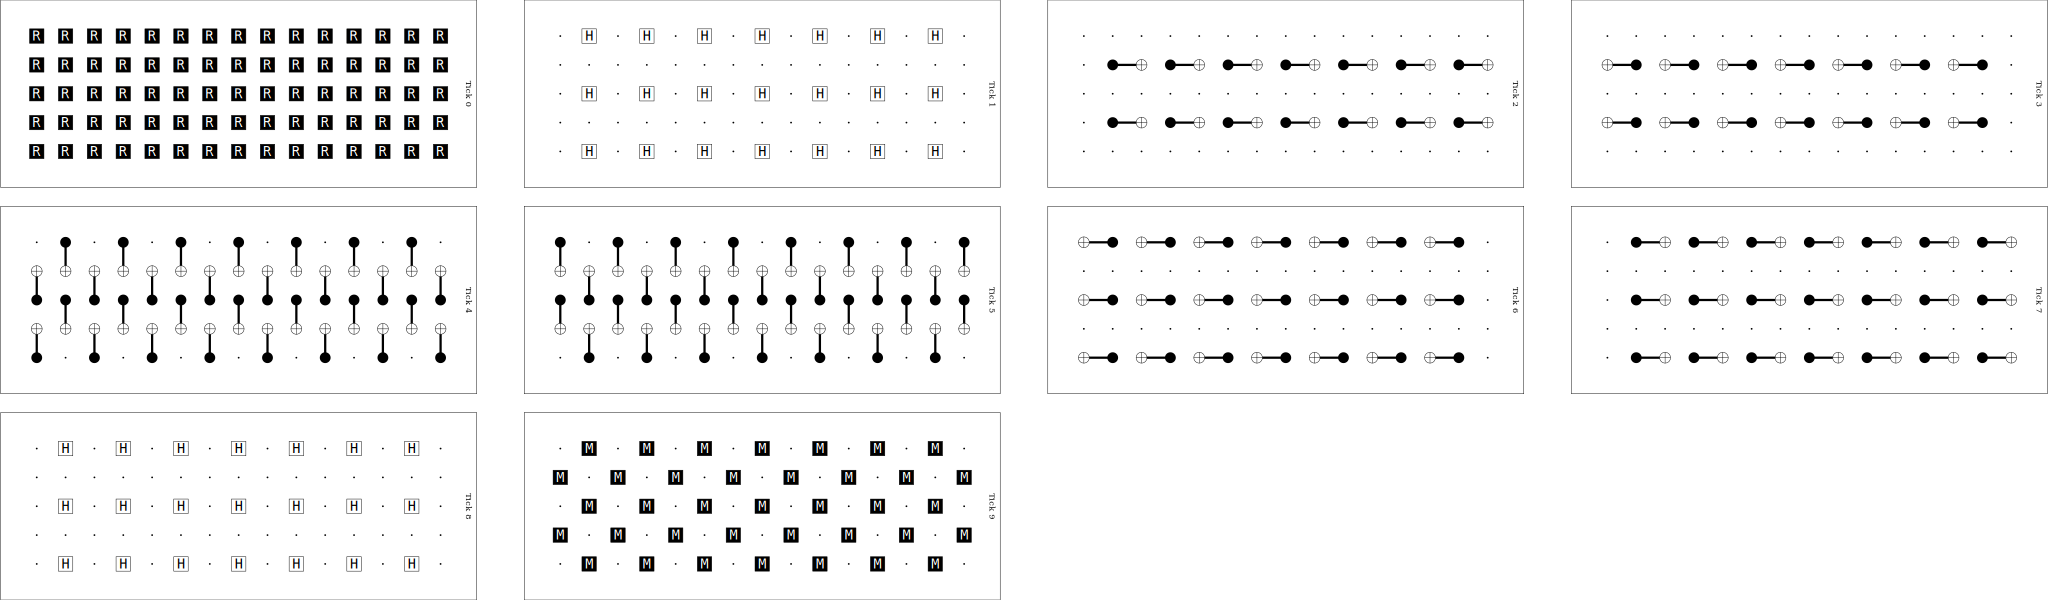

In [2]:
# Ex 1: Two d=3 patches, gap=6 for a wider corridor
# Left patch (0,4), right patch (10,14), corridor interior x=[5,9]
system_ex1 = QECSystem()
system_ex1.add_patch(UnrotatedSurfaceCode(distance=3), name='p1')
system_ex1.add_patch(UnrotatedSurfaceCode(distance=3), name='p2', offset=(10, 0))

system_ex1.register_coupler(
    UnrotatedMultiPatchCoupler(),
    patch_names=['p1', 'p2'],
    name='c12',
    path_axis='vertical',
    center_axis=7.0,
)

cp = system_ex1.coupler_patches['c12']
print(f"Coupler: {len(cp.data_indices)} data, {len(cp.syndrome_indices)} syndrome")
print(f"Data x-coords: {sorted(set(cp.qubit_coords[i][0] for i in cp.data_indices))}")
print(f"Stabilizers: {len(cp.stabilizers)}, Conflicts: {len(cp.conflicting_stabilizer_coords)}")

visualize_coupler(system_ex1, 'c12')

## Ex 2: Three-patch ZZZ

Three d=3 patches: p1 (left, top), p2 (right, top), p3 (left, bottom).
Vertical corridor at x=5 connecting all three.

Coupler: 27 data, 28 syndrome
Data x-coords: [5.0, 6.0, 7.0, 8.0, 9.0]
Stabilizers: 34, Conflicts: 6
Applying first round of syndrome extraction...


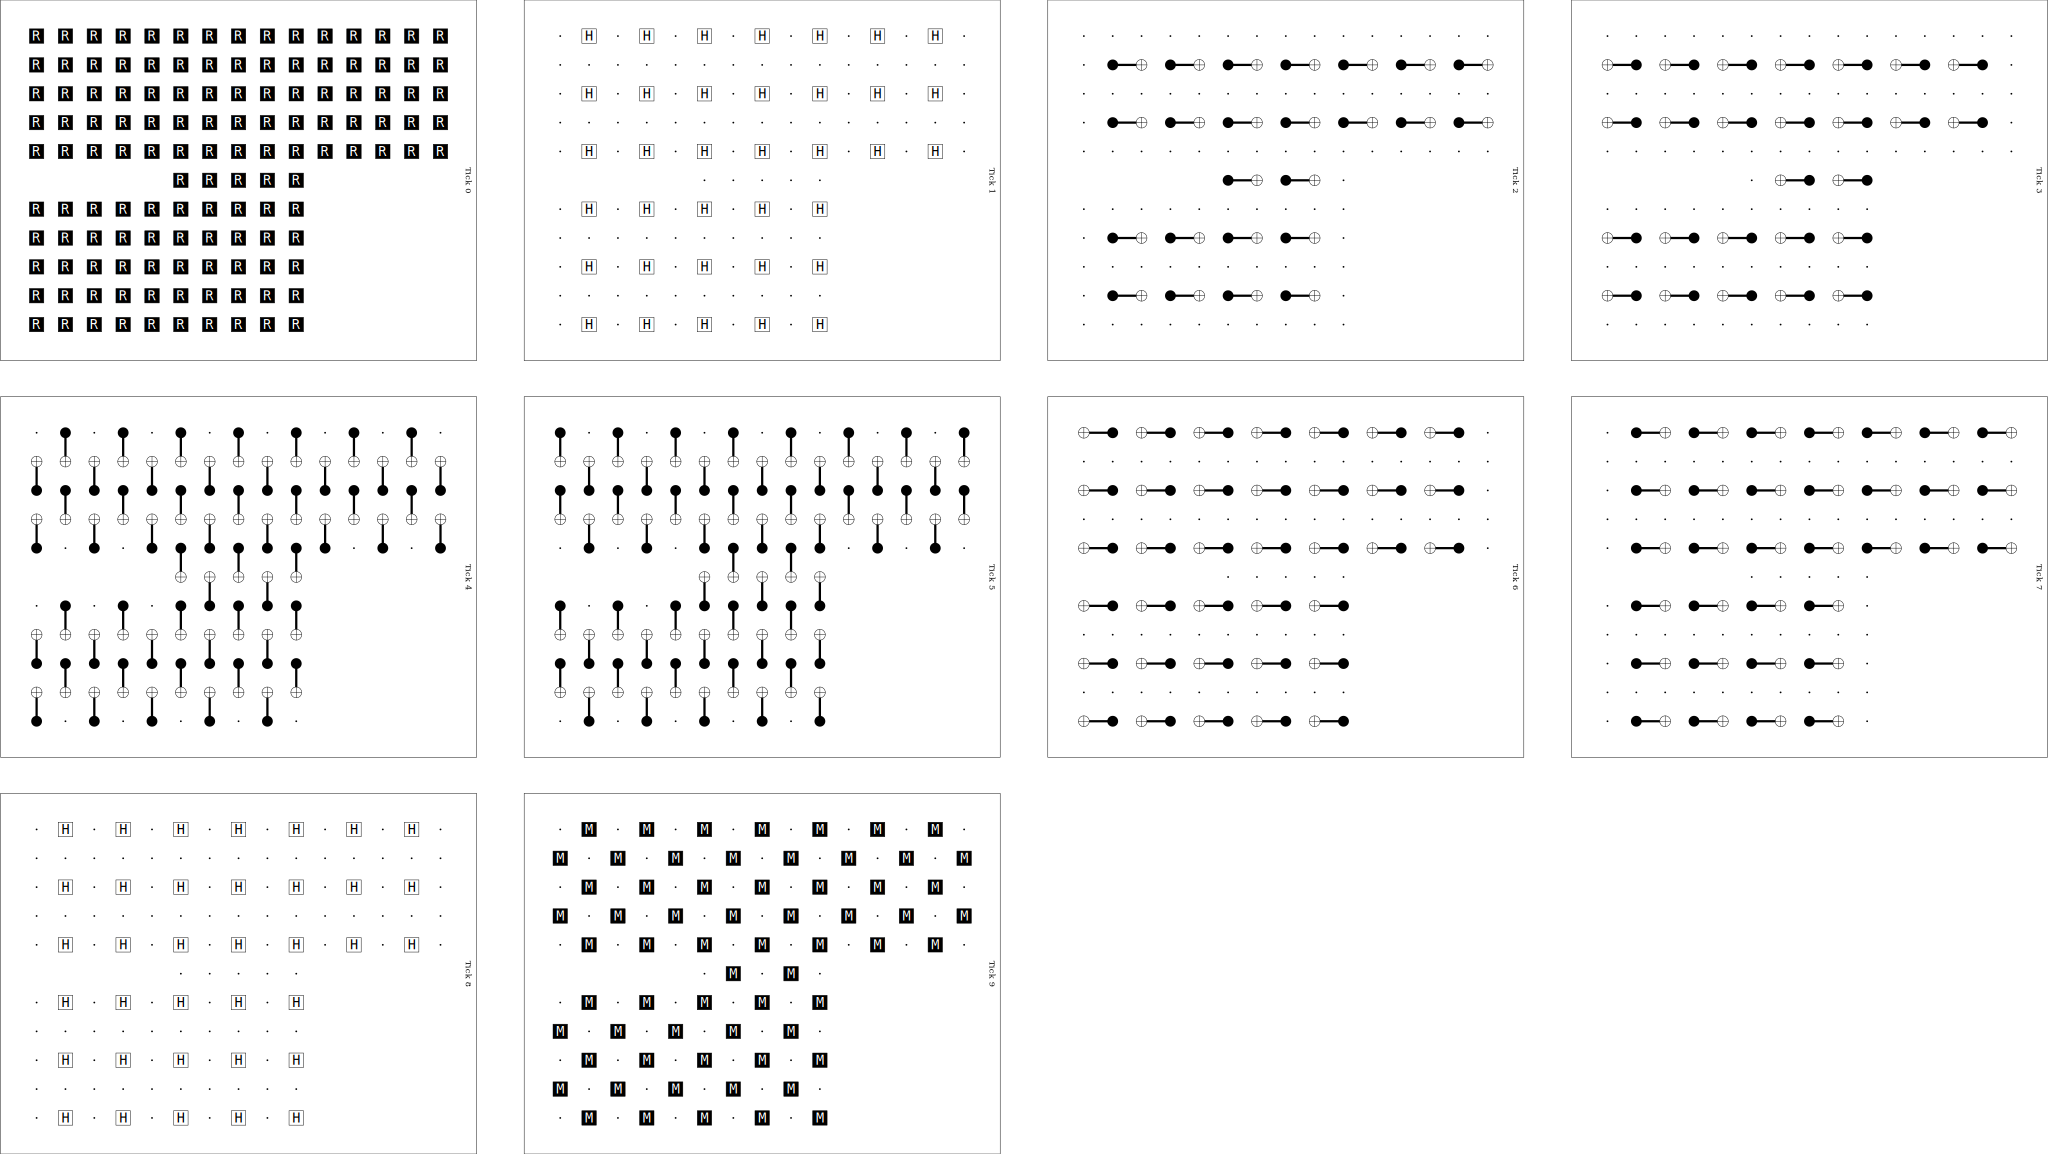

In [3]:
# Ex 2: Three d=3 patches: p1 (left top), p2 (right top), p3 (left bottom)
# Gap of 6 between left/right groups, corridor interior x=[5,9]
system_ex2 = QECSystem()
system_ex2.add_patch(UnrotatedSurfaceCode(distance=3), name='p1')                     # (0,4, 0,4)
system_ex2.add_patch(UnrotatedSurfaceCode(distance=3), name='p2', offset=(10, 0))     # (10,14, 0,4)
system_ex2.add_patch(UnrotatedSurfaceCode(distance=3), name='p3', offset=(0, 6))      # (0,4, 6,10)

system_ex2.register_coupler(
    UnrotatedMultiPatchCoupler(),
    patch_names=['p1', 'p2', 'p3'],
    name='zzz',
    path_axis='vertical',
    center_axis=7.0,
)

cp2 = system_ex2.coupler_patches['zzz']
print(f"Coupler: {len(cp2.data_indices)} data, {len(cp2.syndrome_indices)} syndrome")
print(f"Data x-coords: {sorted(set(cp2.qubit_coords[i][0] for i in cp2.data_indices))}")
print(f"Stabilizers: {len(cp2.stabilizers)}, Conflicts: {len(cp2.conflicting_stabilizer_coords)}")

visualize_coupler(system_ex2, 'zzz')

## Ex 3: Multi-patch with different distances

4 patches: p1 (d=3, left top), p2 (d=5, right), p3 (d=3, left bottom), p4 (d=3, right bottom).
Vertical corridor at x=5.

Patch bounds:
  p1: (0.0, 4, 0.0, 4)
  p2: (14.0, 22, -2.0, 6)
  p3: (0.0, 4, 6.0, 10)
  p4: (14.0, 18, 8.0, 12)

Coupler: 67 data, 68 syndrome
Data x-coords: [5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0]
Stabilizers: 78, Conflicts: 10
Applying first round of syndrome extraction...


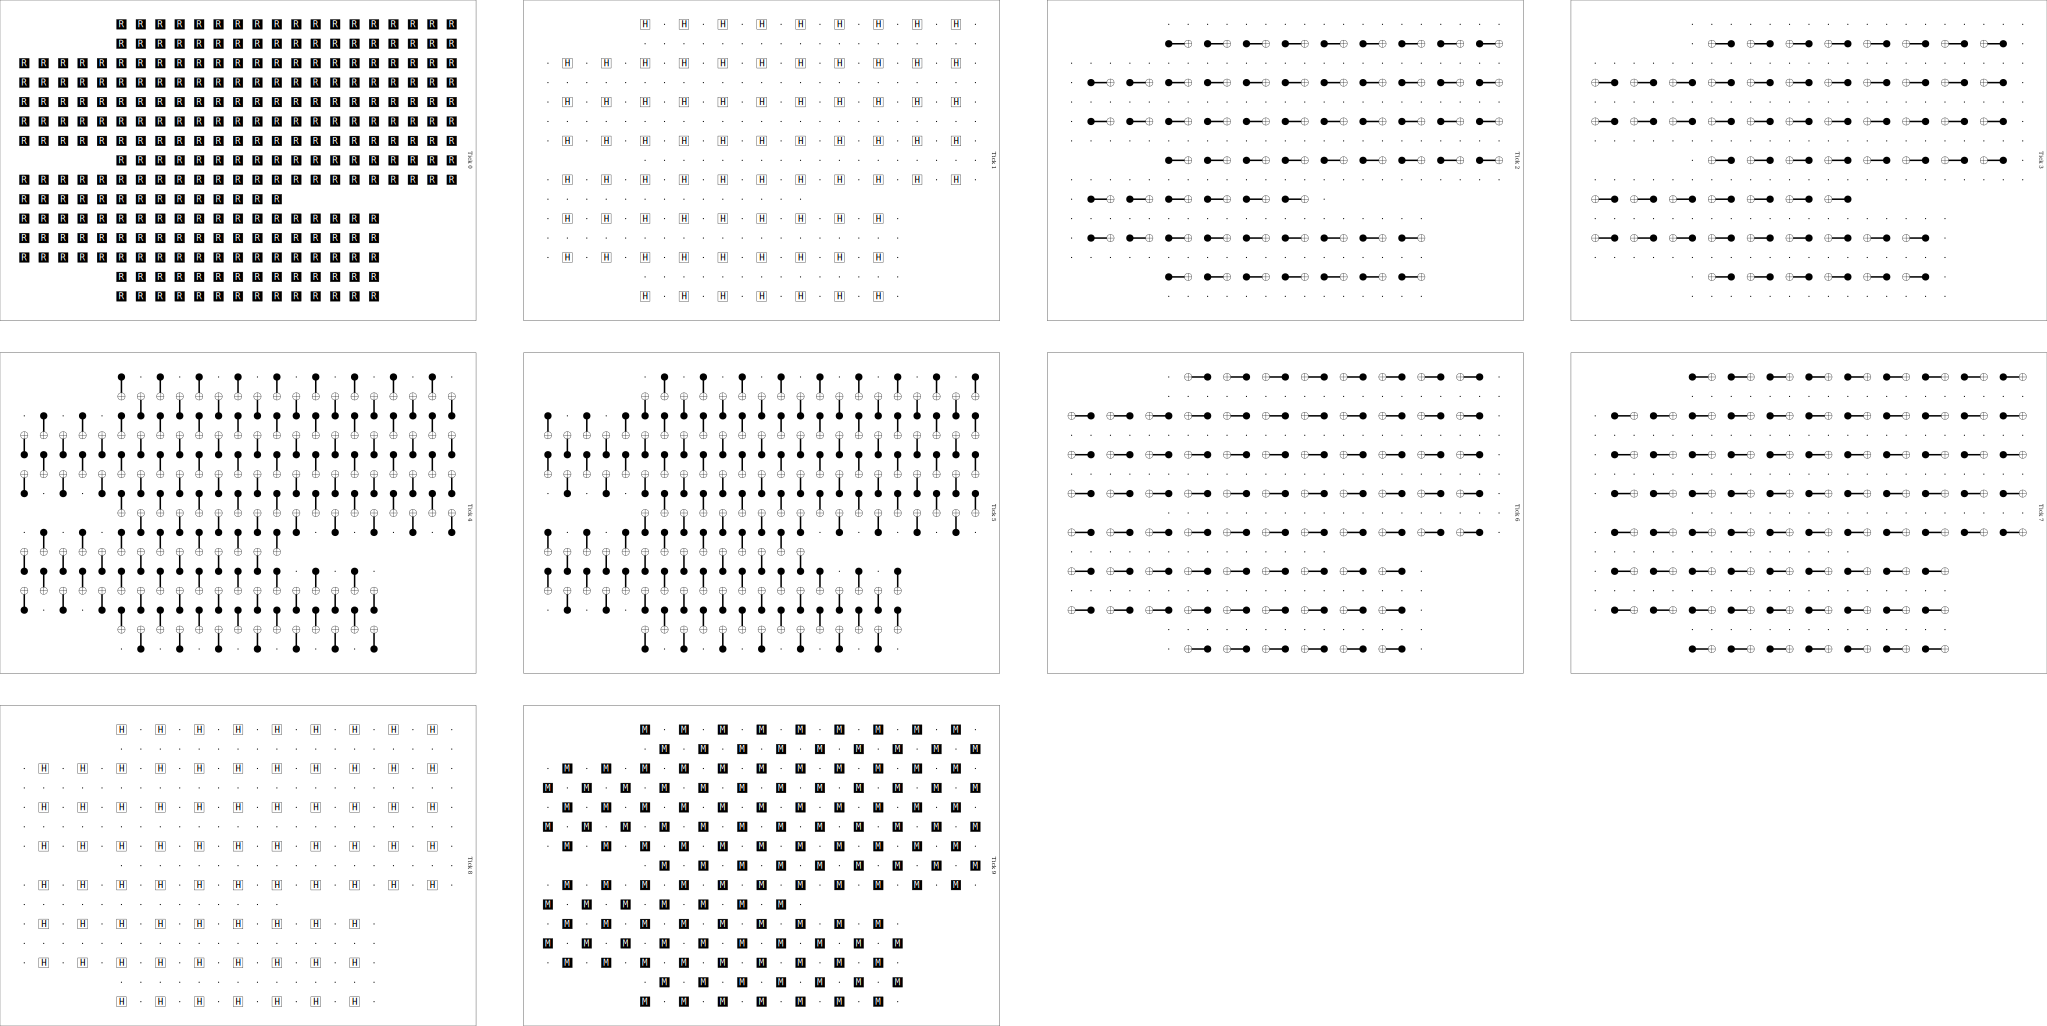

In [4]:
# Ex 3: 4 patches with mixed distances
# Left patches at x=0..4 (d=3) and x=0..8 (d=5)
# Right patches at x=14..18 (d=3)
# center_axis=11 → corridor interior x=[9,13]
system_ex3 = QECSystem()
system_ex3.add_patch(UnrotatedSurfaceCode(distance=3), name='p1')                     # (0,4, 0,4)
system_ex3.add_patch(UnrotatedSurfaceCode(distance=5), name='p2', offset=(14, -2))    # (14,22, -2,6)
system_ex3.add_patch(UnrotatedSurfaceCode(distance=3), name='p3', offset=(0, 6))      # (0,4, 6,10)
system_ex3.add_patch(UnrotatedSurfaceCode(distance=3), name='p4', offset=(14, 8))     # (14,18, 8,12)

print("Patch bounds:")
for name in ['p1', 'p2', 'p3', 'p4']:
    print(f"  {name}: {system_ex3.patches[name][0]._get_bounds()}")

system_ex3.register_coupler(
    UnrotatedMultiPatchCoupler(),
    patch_names=['p1', 'p2', 'p3', 'p4'],
    name='multi',
    path_axis='vertical',
    center_axis=9.0,
)

cp3 = system_ex3.coupler_patches['multi']
print(f"\nCoupler: {len(cp3.data_indices)} data, {len(cp3.syndrome_indices)} syndrome")
print(f"Data x-coords: {sorted(set(cp3.qubit_coords[i][0] for i in cp3.data_indices))}")
print(f"Stabilizers: {len(cp3.stabilizers)}, Conflicts: {len(cp3.conflicting_stabilizer_coords)}")

visualize_coupler(system_ex3, 'multi')

## Ex 3b: 5-patch Z̄₁Z̄₂Z̄₃Z̄₅ (reference image Ex 3)

Reproducing `processing/unrotated_multi_coupler.png` Ex 3:
- 1 start patch (bottom endpoint of the vertical path)
- 4 side patches (2 left, 2 right) at different heights with different distances
- `start_patch=4` specifies the 5th patch (index 4) as the path endpoint

Patch bounds:
  p1: (-2.0, 2, 2.0, 6)
  p2: (10.0, 14, 2.0, 6)
  p3: (-2.0, 2, 8.0, 12)
  p4: (10.0, 14, 8.0, 12)
  p_end: (4.0, 8, 18.0, 22)

Coupler: 48 data, 52 syndrome
Data x-coords: [3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
Stabilizers: 62, Conflicts: 10
Applying first round of syndrome extraction...


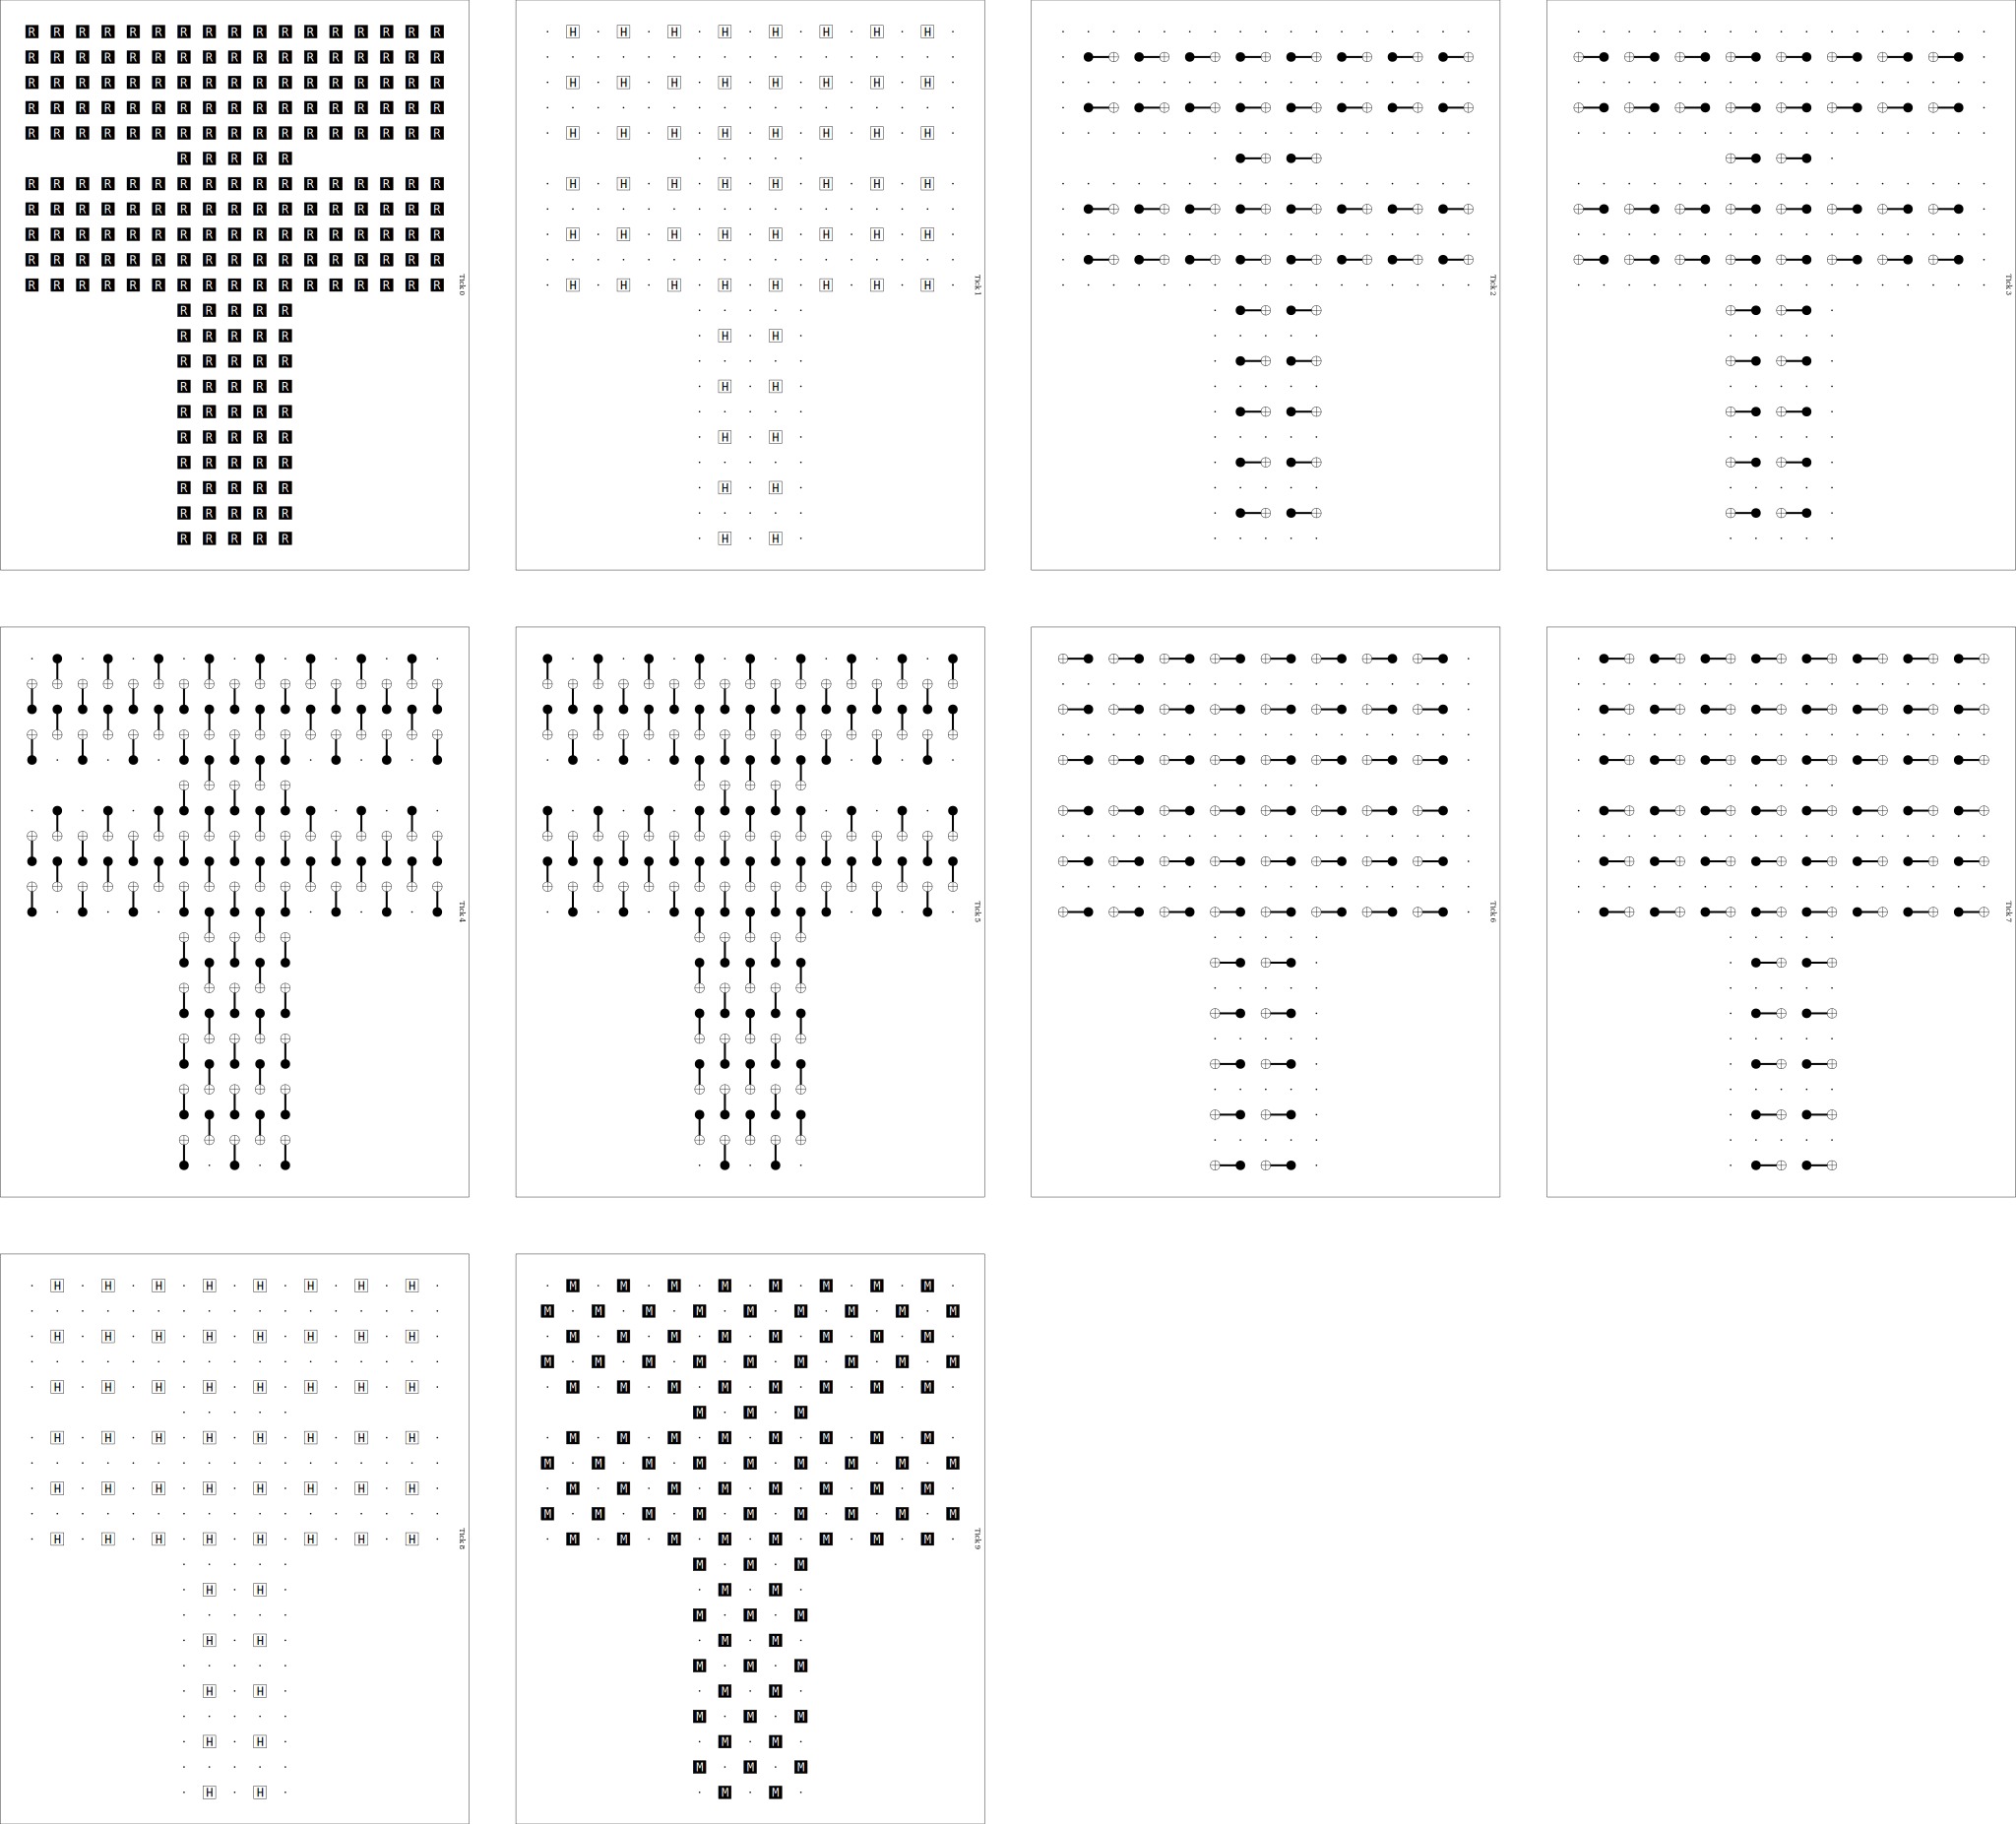

In [5]:
# Ex 3b: 5-patch — 1 start patch (bottom) + 4 side patches (2 left, 2 right)
# Start patch at (4,8, 18,22) defines corridor x=[4,8]
# Left patches: right_edge=2 < 4 (gap of 2), Right patches: left_edge=10 > 8 (gap of 2)
system_ex3b = QECSystem()
system_ex3b.add_patch(UnrotatedSurfaceCode(distance=3), name='p1', offset=(-2, 2))     # (-2,2, 2,6) — left top
system_ex3b.add_patch(UnrotatedSurfaceCode(distance=3), name='p2', offset=(10, 2))     # (10,14, 2,6) — right top
system_ex3b.add_patch(UnrotatedSurfaceCode(distance=3), name='p3', offset=(-2, 8))     # (-2,2, 8,12) — left mid
system_ex3b.add_patch(UnrotatedSurfaceCode(distance=3), name='p4', offset=(10, 8))     # (10,14, 8,12) — right mid
system_ex3b.add_patch(UnrotatedSurfaceCode(distance=3), name='p_end', offset=(4, 18))  # (4,8, 18,22) — start (bottom)

print("Patch bounds:")
for name in ['p1', 'p2', 'p3', 'p4', 'p_end']:
    print(f"  {name}: {system_ex3b.patches[name][0]._get_bounds()}")

# start_patch=4 → p_end is the path endpoint
system_ex3b.register_coupler(
    UnrotatedMultiPatchCoupler(),
    patch_names=['p1', 'p2', 'p3', 'p4', 'p_end'],
    name='ex3b',
    path_axis='vertical',
    start_patch=4,
)

cp3b = system_ex3b.coupler_patches['ex3b']
print(f"\nCoupler: {len(cp3b.data_indices)} data, {len(cp3b.syndrome_indices)} syndrome")
print(f"Data x-coords: {sorted(set(cp3b.qubit_coords[i][0] for i in cp3b.data_indices))}")
print(f"Stabilizers: {len(cp3b.stabilizers)}, Conflicts: {len(cp3b.conflicting_stabilizer_coords)}")

visualize_coupler(system_ex3b, 'ex3b')

---

# Lattice Surgery Experiments

All patches need π/2 rotation so their Z boundaries face the vertical corridor.
After rotation, `reset_rotation_angle()` ensures the SE block uses standard direction vectors.

## Exp 1: 2-patch ZZ measurement (with detectors)

In [ ]:
d = 3
rounds = d
coupler_name = 'c12'

# Rotate patches π/2 so Z boundary faces left/right (toward corridor)
p1 = UnrotatedSurfaceCode(distance=d)
p1.rotate_coords(np.pi/2); p1.reset_rotation_angle()

p2 = UnrotatedSurfaceCode(distance=d)
p2.rotate_coords(np.pi/2); p2.reset_rotation_angle()

system = QECSystem()
system.add_patch(p1, name='p1')
system.add_patch(p2, name='p2', offset=(10, 0))
system.register_coupler(UnrotatedMultiPatchCoupler(), patch_names=['p1', 'p2'],
                        name=coupler_name, path_axis='vertical', center_axis=7.0)

num_qubits = system.num_qubits
cp = system.coupler_patches[coupler_name]

tracker = SyndromeTracker(num_qubits=num_qubits, expected_num_logicals=system.num_logicals)
builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=True)
builder.write_coordinates()

# Init code patch data in Z
init_dict = {q: 'Z' for q in system.data_indices if system.index_to_owner_map[q] != coupler_name}
builder.initialize(init_dict=init_dict, n=num_qubits)

# SE before coupler
se = UnrotatedSurfaceCodeExtractionBlock(system)
builder.apply_syndrome_extraction(circuit_chunk=se.circuit, rounds=rounds)

# Activate coupler + init coupler data in X (complementary to Z measurement)
builder.activate_coupler(coupler_name)
coupler_data_global = [system.local_to_global_map[coupler_name][q] for q in cp.data_indices]
coupler_init = {q: 'X' for q in coupler_data_global}
builder.initialize(init_dict=coupler_init, n=num_qubits)

# SE with coupler active
se2 = UnrotatedSurfaceCodeExtractionBlock(system)
builder.apply_syndrome_extraction(circuit_chunk=se2.circuit, rounds=rounds)

# Readout
measure_dict = {q: 'Z' for q in system.data_indices if system.index_to_owner_map[q] != coupler_name}
measure_dict.update(coupler_init)
builder.apply_data_readout(final_measurements=measure_dict)

circuit = builder.circuit
print(f"Circuit: {circuit.num_qubits} qubits, {circuit.num_detectors} detectors, {circuit.num_observables} obs")
dem = circuit.detector_error_model(decompose_errors=True)
print(f"DEM OK: {dem.num_detectors} det, {dem.num_observables} obs")

circuit.diagram("detslice-with-ops-svg")

## Exp 2: 3-patch ZZZ measurement (with detectors)

In [ ]:
d = 3
rounds = d
coupler_name = 'zzz'

p1 = UnrotatedSurfaceCode(distance=d)
p1.rotate_coords(np.pi/2); p1.reset_rotation_angle()

p2 = UnrotatedSurfaceCode(distance=d)
p2.rotate_coords(np.pi/2); p2.reset_rotation_angle()

p3 = UnrotatedSurfaceCode(distance=d)
p3.rotate_coords(np.pi/2); p3.reset_rotation_angle()

system = QECSystem()
system.add_patch(p1, name='p1')                                                  # (0,4, 0,4)
system.add_patch(p2, name='p2', offset=(10, 0))                                  # (10,14, 0,4)
system.add_patch(p3, name='p3', offset=(0, 6))                                   # (0,4, 6,10)
system.register_coupler(UnrotatedMultiPatchCoupler(), patch_names=['p1', 'p2', 'p3'],
                        name=coupler_name, path_axis='vertical', center_axis=7.0)

num_qubits = system.num_qubits
cp = system.coupler_patches[coupler_name]

tracker = SyndromeTracker(num_qubits=num_qubits, expected_num_logicals=system.num_logicals)
builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=True)
builder.write_coordinates()

init_dict = {q: 'Z' for q in system.data_indices if system.index_to_owner_map[q] != coupler_name}
builder.initialize(init_dict=init_dict, n=num_qubits)

se = UnrotatedSurfaceCodeExtractionBlock(system)
builder.apply_syndrome_extraction(circuit_chunk=se.circuit, rounds=rounds)

builder.activate_coupler(coupler_name)
coupler_data_global = [system.local_to_global_map[coupler_name][q] for q in cp.data_indices]
coupler_init = {q: 'X' for q in coupler_data_global}
builder.initialize(init_dict=coupler_init, n=num_qubits)

se2 = UnrotatedSurfaceCodeExtractionBlock(system)
builder.apply_syndrome_extraction(circuit_chunk=se2.circuit, rounds=rounds)

measure_dict = {q: 'Z' for q in system.data_indices if system.index_to_owner_map[q] != coupler_name}
measure_dict.update(coupler_init)
builder.apply_data_readout(final_measurements=measure_dict)

circuit = builder.circuit
print(f"Circuit: {circuit.num_qubits} qubits, {circuit.num_detectors} detectors, {circuit.num_observables} obs")
dem = circuit.detector_error_model(decompose_errors=True)
print(f"DEM OK: {dem.num_detectors} det, {dem.num_observables} obs")

circuit.diagram("detslice-with-ops-svg")

## Exp 3: 5-patch with selective 4-patch Z₄ measurement

5 patches in the system, but only 4 participate in the Z product measurement.
p1 (left-top) is idle — not part of the coupler.
This demonstrates selective joint measurement for distillation circuits.

In [ ]:
d = 3
rounds = d
coupler_name = 'z4'

# 5 patches, all rotated π/2
patch_configs = {
    'p1': (-2, 2),    # left-top — IDLE (not in coupler)
    'p2': (10, 2),    # right-top — interact
    'p3': (-2, 8),    # left-bottom — interact
    'p4': (10, 8),    # right-bottom — interact
    'p5': (-2, 14),   # bottom-left — interact
}

system = QECSystem()
for name, offset in patch_configs.items():
    p = UnrotatedSurfaceCode(distance=d)
    p.rotate_coords(np.pi/2); p.reset_rotation_angle()
    system.add_patch(p, name=name, offset=offset)

print("Patch bounds:")
for name in patch_configs:
    role = 'IDLE' if name == 'p1' else 'interact'
    print(f"  {name} ({role}): {system.patches[name][0]._get_bounds()}")

# Register coupler with only 4 patches (skip p1)
system.register_coupler(
    UnrotatedMultiPatchCoupler(),
    patch_names=['p2', 'p3', 'p4', 'p5'],
    name=coupler_name,
    path_axis='vertical',
    center_axis=6.0,
)

cp = system.coupler_patches[coupler_name]
num_qubits = system.num_qubits

tracker = SyndromeTracker(num_qubits=num_qubits, expected_num_logicals=system.num_logicals)
builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=True)
builder.write_coordinates()

init_dict = {q: 'Z' for q in system.data_indices if system.index_to_owner_map[q] != coupler_name}
builder.initialize(init_dict=init_dict, n=num_qubits)

se = UnrotatedSurfaceCodeExtractionBlock(system)
builder.apply_syndrome_extraction(circuit_chunk=se.circuit, rounds=rounds)

builder.activate_coupler(coupler_name)
coupler_data_global = [system.local_to_global_map[coupler_name][q] for q in cp.data_indices]
coupler_init = {q: 'X' for q in coupler_data_global}
builder.initialize(init_dict=coupler_init, n=num_qubits)

se2 = UnrotatedSurfaceCodeExtractionBlock(system)
builder.apply_syndrome_extraction(circuit_chunk=se2.circuit, rounds=rounds)

measure_dict = {q: 'Z' for q in system.data_indices if system.index_to_owner_map[q] != coupler_name}
measure_dict.update(coupler_init)
builder.apply_data_readout(final_measurements=measure_dict)

circuit = builder.circuit
print(f"\nCircuit: {circuit.num_qubits} qubits, {circuit.num_detectors} detectors, {circuit.num_observables} obs")
dem = circuit.detector_error_model(decompose_errors=True)
print(f"DEM OK: {dem.num_detectors} det, {dem.num_observables} obs")

circuit.diagram("detslice-with-ops-svg")

## Exp 4: 5-patch mixed distances, selective ZZZZ

5 patches with mixed code distances (d=3 and d=4). p3 is idle; p1, p2, p4, p5 participate in ZZZZ measurement.

Note: all interacting patches are side patches (left/right of corridor). Perpendicular
endpoint boundaries cause CNOT scheduling conflicts in the 6-tick SE schedule, so endpoints
are not currently supported. Future work: custom SE schedule or diagonal bridge geometry.

In [ ]:
d = 3
rounds = d
coupler_name = 'z4'

# Layout:
# p1(-2,2) d=3     p3(12,2) d=3  ← IDLE
# p2(-2,8) d=3     p4(10,8) d=4
# p5(-2,16) d=3
patch_configs = [
    ('p1', 3, (-2, 2)),    # left-top, interact
    ('p2', 3, (-2, 8)),    # left-mid, interact
    ('p3', 3, (12, 2)),    # right-top, shifted right, IDLE
    ('p4', 4, (10, 8)),    # right-mid, d=4, interact
    ('p5', 3, (-2, 16)),   # left-bottom, interact
]

system = QECSystem()
for name, dist, offset in patch_configs:
    p = UnrotatedSurfaceCode(distance=dist)
    p.rotate_coords(np.pi/2); p.reset_rotation_angle()
    system.add_patch(p, name=name, offset=offset)

print("Patch bounds:")
for name, dist, _ in patch_configs:
    role = 'IDLE' if name == 'p3' else 'interact'
    print(f"  {name} (d={dist}, {role}): {system.patches[name][0]._get_bounds()}")

# Coupler: p1,p2,p4,p5 interact (skip p3)
system.register_coupler(
    UnrotatedMultiPatchCoupler(),
    patch_names=['p1', 'p2', 'p4', 'p5'],
    name=coupler_name,
    path_axis='vertical',
    center_axis=6.0,
)

cp = system.coupler_patches[coupler_name]
num_qubits = system.num_qubits

tracker = SyndromeTracker(num_qubits=num_qubits, expected_num_logicals=system.num_logicals)
builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=True)
builder.write_coordinates()

init_dict = {q: 'Z' for q in system.data_indices if system.index_to_owner_map[q] != coupler_name}
builder.initialize(init_dict=init_dict, n=num_qubits)

se = UnrotatedSurfaceCodeExtractionBlock(system)
builder.apply_syndrome_extraction(circuit_chunk=se.circuit, rounds=rounds)

builder.activate_coupler(coupler_name)
coupler_data_global = [system.local_to_global_map[coupler_name][q] for q in cp.data_indices]
coupler_init = {q: 'X' for q in coupler_data_global}
builder.initialize(init_dict=coupler_init, n=num_qubits)

se2 = UnrotatedSurfaceCodeExtractionBlock(system)
builder.apply_syndrome_extraction(circuit_chunk=se2.circuit, rounds=rounds)

measure_dict = {q: 'Z' for q in system.data_indices if system.index_to_owner_map[q] != coupler_name}
measure_dict.update(coupler_init)
builder.apply_data_readout(final_measurements=measure_dict)

circuit = builder.circuit
print(f"\nCircuit: {circuit.num_qubits} qubits, {circuit.num_detectors} detectors, {circuit.num_observables} obs")
dem = circuit.detector_error_model(decompose_errors=True)
print(f"DEM OK: {dem.num_detectors} det, {dem.num_observables} obs")

circuit.diagram("detslice-with-ops-svg")

## Observable Count vs Initial State

For Z product measurement:
- Init |0⟩ (Z commutes with Z measurement): N logical observables preserved
- Init |+⟩ (X anti-commutes with Z measurement): N-1 observables (one DOF consumed)

In [ ]:
def run_observable_test(n_patches, init_basis, description):
    """Test observable count for n-patch Z product measurement."""
    d = 3
    system = QECSystem()
    offsets_left = [(-2, i*6) for i in range(n_patches // 2 + n_patches % 2)]
    offsets_right = [(10, i*6) for i in range(n_patches // 2)]
    all_offsets = []
    for i, off in enumerate(offsets_left):
        all_offsets.append((f'L{i}', off))
    for i, off in enumerate(offsets_right):
        all_offsets.append((f'R{i}', off))
    all_offsets = all_offsets[:n_patches]

    for name, offset in all_offsets:
        p = UnrotatedSurfaceCode(distance=d)
        p.rotate_coords(np.pi/2); p.reset_rotation_angle()
        system.add_patch(p, name=name, offset=offset)

    patch_names = [name for name, _ in all_offsets]
    system.register_coupler(UnrotatedMultiPatchCoupler(),
        patch_names=patch_names, name='c', path_axis='vertical', center_axis=6.0)

    cp = system.coupler_patches['c']
    tracker = SyndromeTracker(num_qubits=system.num_qubits, expected_num_logicals=system.num_logicals)
    builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=True)
    builder.write_coordinates()

    init = {q: init_basis for q in system.data_indices if system.index_to_owner_map[q] != 'c'}
    builder.initialize(init_dict=init, n=system.num_qubits)
    se = UnrotatedSurfaceCodeExtractionBlock(system)
    builder.apply_syndrome_extraction(circuit_chunk=se.circuit, rounds=d)

    builder.activate_coupler('c')
    cd = [system.local_to_global_map['c'][q] for q in cp.data_indices]
    ci = {q: 'X' for q in cd}
    builder.initialize(init_dict=ci, n=system.num_qubits)
    se2 = UnrotatedSurfaceCodeExtractionBlock(system)
    builder.apply_syndrome_extraction(circuit_chunk=se2.circuit, rounds=d)

    m = {q: init_basis for q in system.data_indices if system.index_to_owner_map[q] != 'c'}
    m.update(ci)
    builder.apply_data_readout(final_measurements=m)

    n_obs = builder.circuit.num_observables
    expected = n_patches if init_basis == 'Z' else n_patches - 1
    status = '✓' if n_obs == expected else '✗'
    print(f"  {description}: {n_obs} obs (expected {expected}) {status}")

print("=== Observable count: Z product measurement ===")
for n in [2, 3, 4]:
    print(f"\n{n}-patch:")
    run_observable_test(n, 'Z', f'Init |0⟩ (commutes)')
    run_observable_test(n, 'X', f'Init |+⟩ (anti-commutes)')

## Observable Count vs Initial State

For Z product measurement:
- Init |0⟩ (Z commutes): all N logical observables preserved
- Init |+⟩ (X anti-commutes): N-1 observables (one DOF consumed by the measurement)